In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from IPython.display import Image, Markdown, display
except ImportError:
    display = None

#experiment: five pre-change distributions -> N(0, 0.1 I_d).
D = 20
CHANGE_TIME = 500
POST_CHANGE_SCALE = 0.1
DISTRIBUTIONS = (
    "gaussian_identity", "gaussian_non_diagonal",
    "uniform", "exponential", "laplace",
)
TIMES = (500, 510, 520, 530, 540)
N_RUNS = 200
SAMPLE_PATH_N_PATHS = 200
SAMPLE_PATH_MAX_TIME = 1000
M_FEATURES = 500
REF_SIZE = 500
BOX_SEED = 456
PATH_SEED = 98765

LAMBDA0 = LAMBDA1 = 1 - 1e-3
ETA = 1e-2
CLIP = (1e-3, 1 - 1e-3)
SEED_OFFSETS = {
    "gaussian_identity": 0, "gaussian_non_diagonal": 1_000_000,
    "uniform": 2_000_000, "exponential": 3_000_000, "laplace": 4_000_000,
}

OUTPUT_DIR = Path.cwd() / "OKAFF_boxes_sample_paths"
BOX_DIR = OUTPUT_DIR / "prepost_boxes"
PATH_DIR = OUTPUT_DIR / "sample_paths"
for folder in (BOX_DIR, PATH_DIR):
    folder.mkdir(parents=True, exist_ok=True)


In [2]:
class AdaptiveForgettingFactor:

    def __init__(self, frequencies):
        self.W = np.asarray(frequencies, dtype=float)
        self.m = self.Lm = None
        self.w = self.Lw = 0.0
        self.lambda_t = LAMBDA0
        self.k = 0

    def update_stat(self, sample):
        projection = self.W @ sample
        feature = np.concatenate((np.cos(projection), np.sin(projection))) / np.sqrt(len(self.W))
        if self.m is None:
            self.m = np.zeros_like(feature)
            self.Lm = np.zeros_like(feature)

        lam = self.lambda_t
        if self.w > 0:
            previous_mean = self.m / self.w
            mean_derivative = (self.Lm - previous_mean * self.Lw) / self.w
        else:
            previous_mean = np.zeros_like(self.m)
            mean_derivative = np.zeros_like(self.m)

        next_m = lam * self.m + feature
        next_w = lam * self.w + 1.0
        next_Lm = self.m + lam * self.Lm
        next_Lw = self.w + lam * self.Lw
        self.m, self.w, self.Lm, self.Lw = next_m, next_w, next_Lm, next_Lw

        mean = self.m / self.w
        statistic = float(np.vdot(mean, mean).real)
        self.k += 1
        if self.k == 1:
            self.lambda_t = float(np.clip(LAMBDA1, *CLIP))
        else:
            gradient = 2.0 * float(np.dot(mean_derivative.ravel(), (previous_mean - feature).ravel()))
            self.lambda_t = float(np.clip(lam - ETA * gradient, *CLIP))
        return statistic


def prechange_sample(rng, n, distribution):
    shape = (int(n), D)
    if distribution == "gaussian_identity":
        return rng.normal(size=shape)
    if distribution == "gaussian_non_diagonal":
        common = rng.normal(size=(int(n), 1))
        independent = rng.normal(size=shape)
        return np.sqrt(3.0) * (
            np.sqrt(0.5) * common + np.sqrt(0.5) * independent
        )
    if distribution == "uniform":
        return rng.uniform(-1.0, 1.0, size=shape)
    if distribution == "exponential":
        return rng.exponential(scale=1.0, size=shape)
    if distribution == "laplace":
        return rng.laplace(loc=0.0, scale=1.0, size=shape)
    raise ValueError(f"Unknown distribution: {distribution}")


def fresh_frequencies(rng, distribution):
    reference = prechange_sample(rng, REF_SIZE, distribution)
    squared_norms = np.sum(reference * reference, axis=1)
    distances = np.maximum(
        squared_norms[:, None] + squared_norms[None, :] - 2.0 * (reference @ reference.T),
        0.0,
    )
    sigma_sq = 0.5 * float(np.median(distances[np.triu_indices(REF_SIZE, k=1)]))
    if sigma_sq <= 0 or not np.isfinite(sigma_sq):
        raise ValueError("The reference must give a finite, positive bandwidth.")
    return rng.normal(0.0, 1.0 / np.sqrt(sigma_sq), size=(M_FEATURES, D))


def simulate(distribution, *, n_runs, horizon, seed, saved_times=None):
    if saved_times is None:
        saved_times = np.arange(1, horizon + 1)
    saved_times = np.asarray(saved_times, dtype=int)
    if (n_runs < 1 or horizon < 1 or REF_SIZE < 2 or M_FEATURES < 1
            or len(saved_times) == 0 or saved_times[0] < 1
            or saved_times[-1] > horizon or np.any(np.diff(saved_times) <= 0)):
        raise ValueError("Invalid simulation settings or saved times.")

    master = np.random.default_rng(seed)
    values = np.empty((n_runs, len(saved_times)), dtype=float)
    for run in range(n_runs):
        ref_rng = np.random.default_rng(master.integers(0, 2**63 - 1))
        detector = AdaptiveForgettingFactor(fresh_frequencies(ref_rng, distribution))
        stream_rng = np.random.default_rng(master.integers(0, 2**63 - 1))

        next_index = 0
        for t in range(1, horizon + 1):
            if t <= CHANGE_TIME:
                sample = prechange_sample(stream_rng, 1, distribution)[0]
            else:
                sample = np.sqrt(POST_CHANGE_SCALE) * stream_rng.normal(size=(1, D))[0]
            statistic = detector.update_stat(sample)
            if t == saved_times[next_index]:
                values[run, next_index] = statistic
                next_index += 1
                if next_index == len(saved_times):
                    break
    return values


def save_figure(fig, directory, stem, *, dpi=220):
    png, pdf = directory / f"{stem}.png", directory / f"{stem}.pdf"
    fig.savefig(png, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.close(fig)
    return png, pdf


In [3]:
box_values = {}
for distribution in DISTRIBUTIONS:
    print(f"Box plots: {distribution}")
    box_values[distribution] = simulate(
        distribution, n_runs=N_RUNS, horizon=TIMES[-1],
        saved_times=TIMES,
        seed=BOX_SEED + 200_000 + SEED_OFFSETS[distribution] + 10_000 * D,
    )


path_values = {}
for distribution in DISTRIBUTIONS:
    print(f"Combined sample paths: {distribution}")
    path_values[distribution] = simulate(
        distribution, n_runs=SAMPLE_PATH_N_PATHS,
        horizon=SAMPLE_PATH_MAX_TIME,
        seed=PATH_SEED + SEED_OFFSETS[distribution] + 10_000 * D,
    )


Box plots: gaussian_identity
Box plots: gaussian_non_diagonal
Box plots: uniform
Box plots: exponential
Box plots: laplace
Combined sample paths: gaussian_identity
Combined sample paths: gaussian_non_diagonal
Combined sample paths: uniform
Combined sample paths: exponential
Combined sample paths: laplace


### pre/post empirical box plots: t=500 and t=510

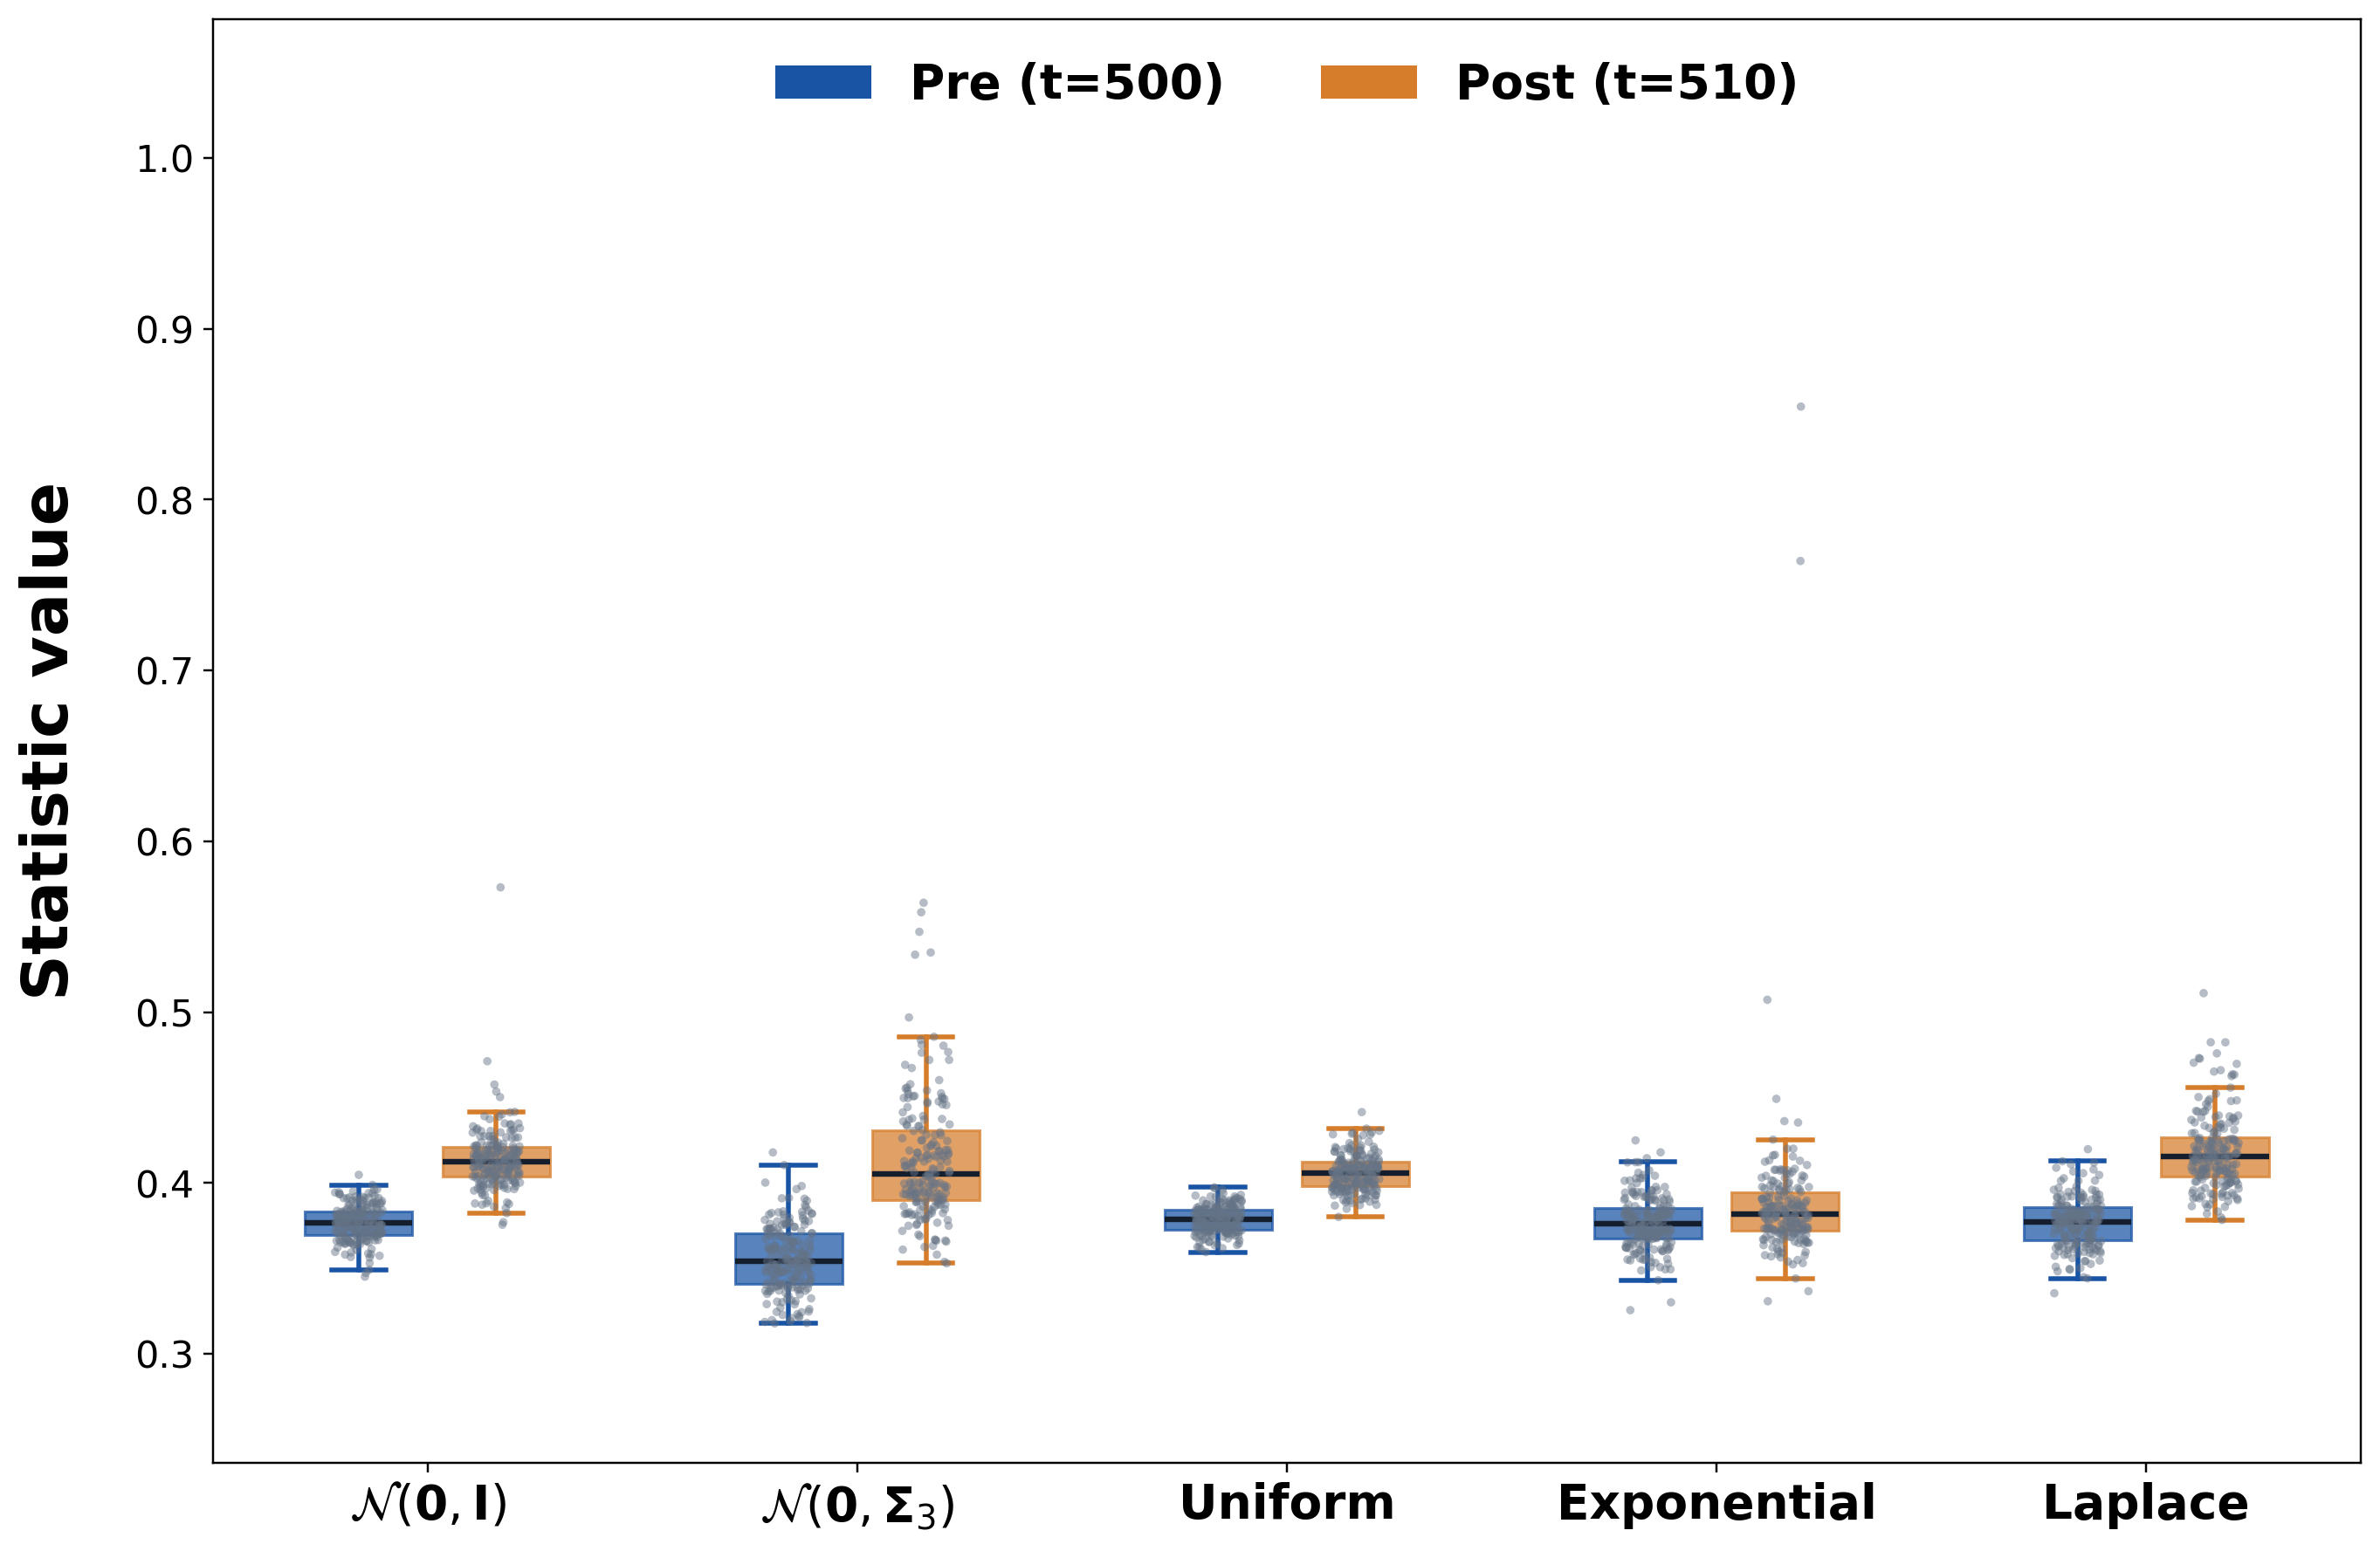

### pre/post empirical box plots: t=500 and t=520

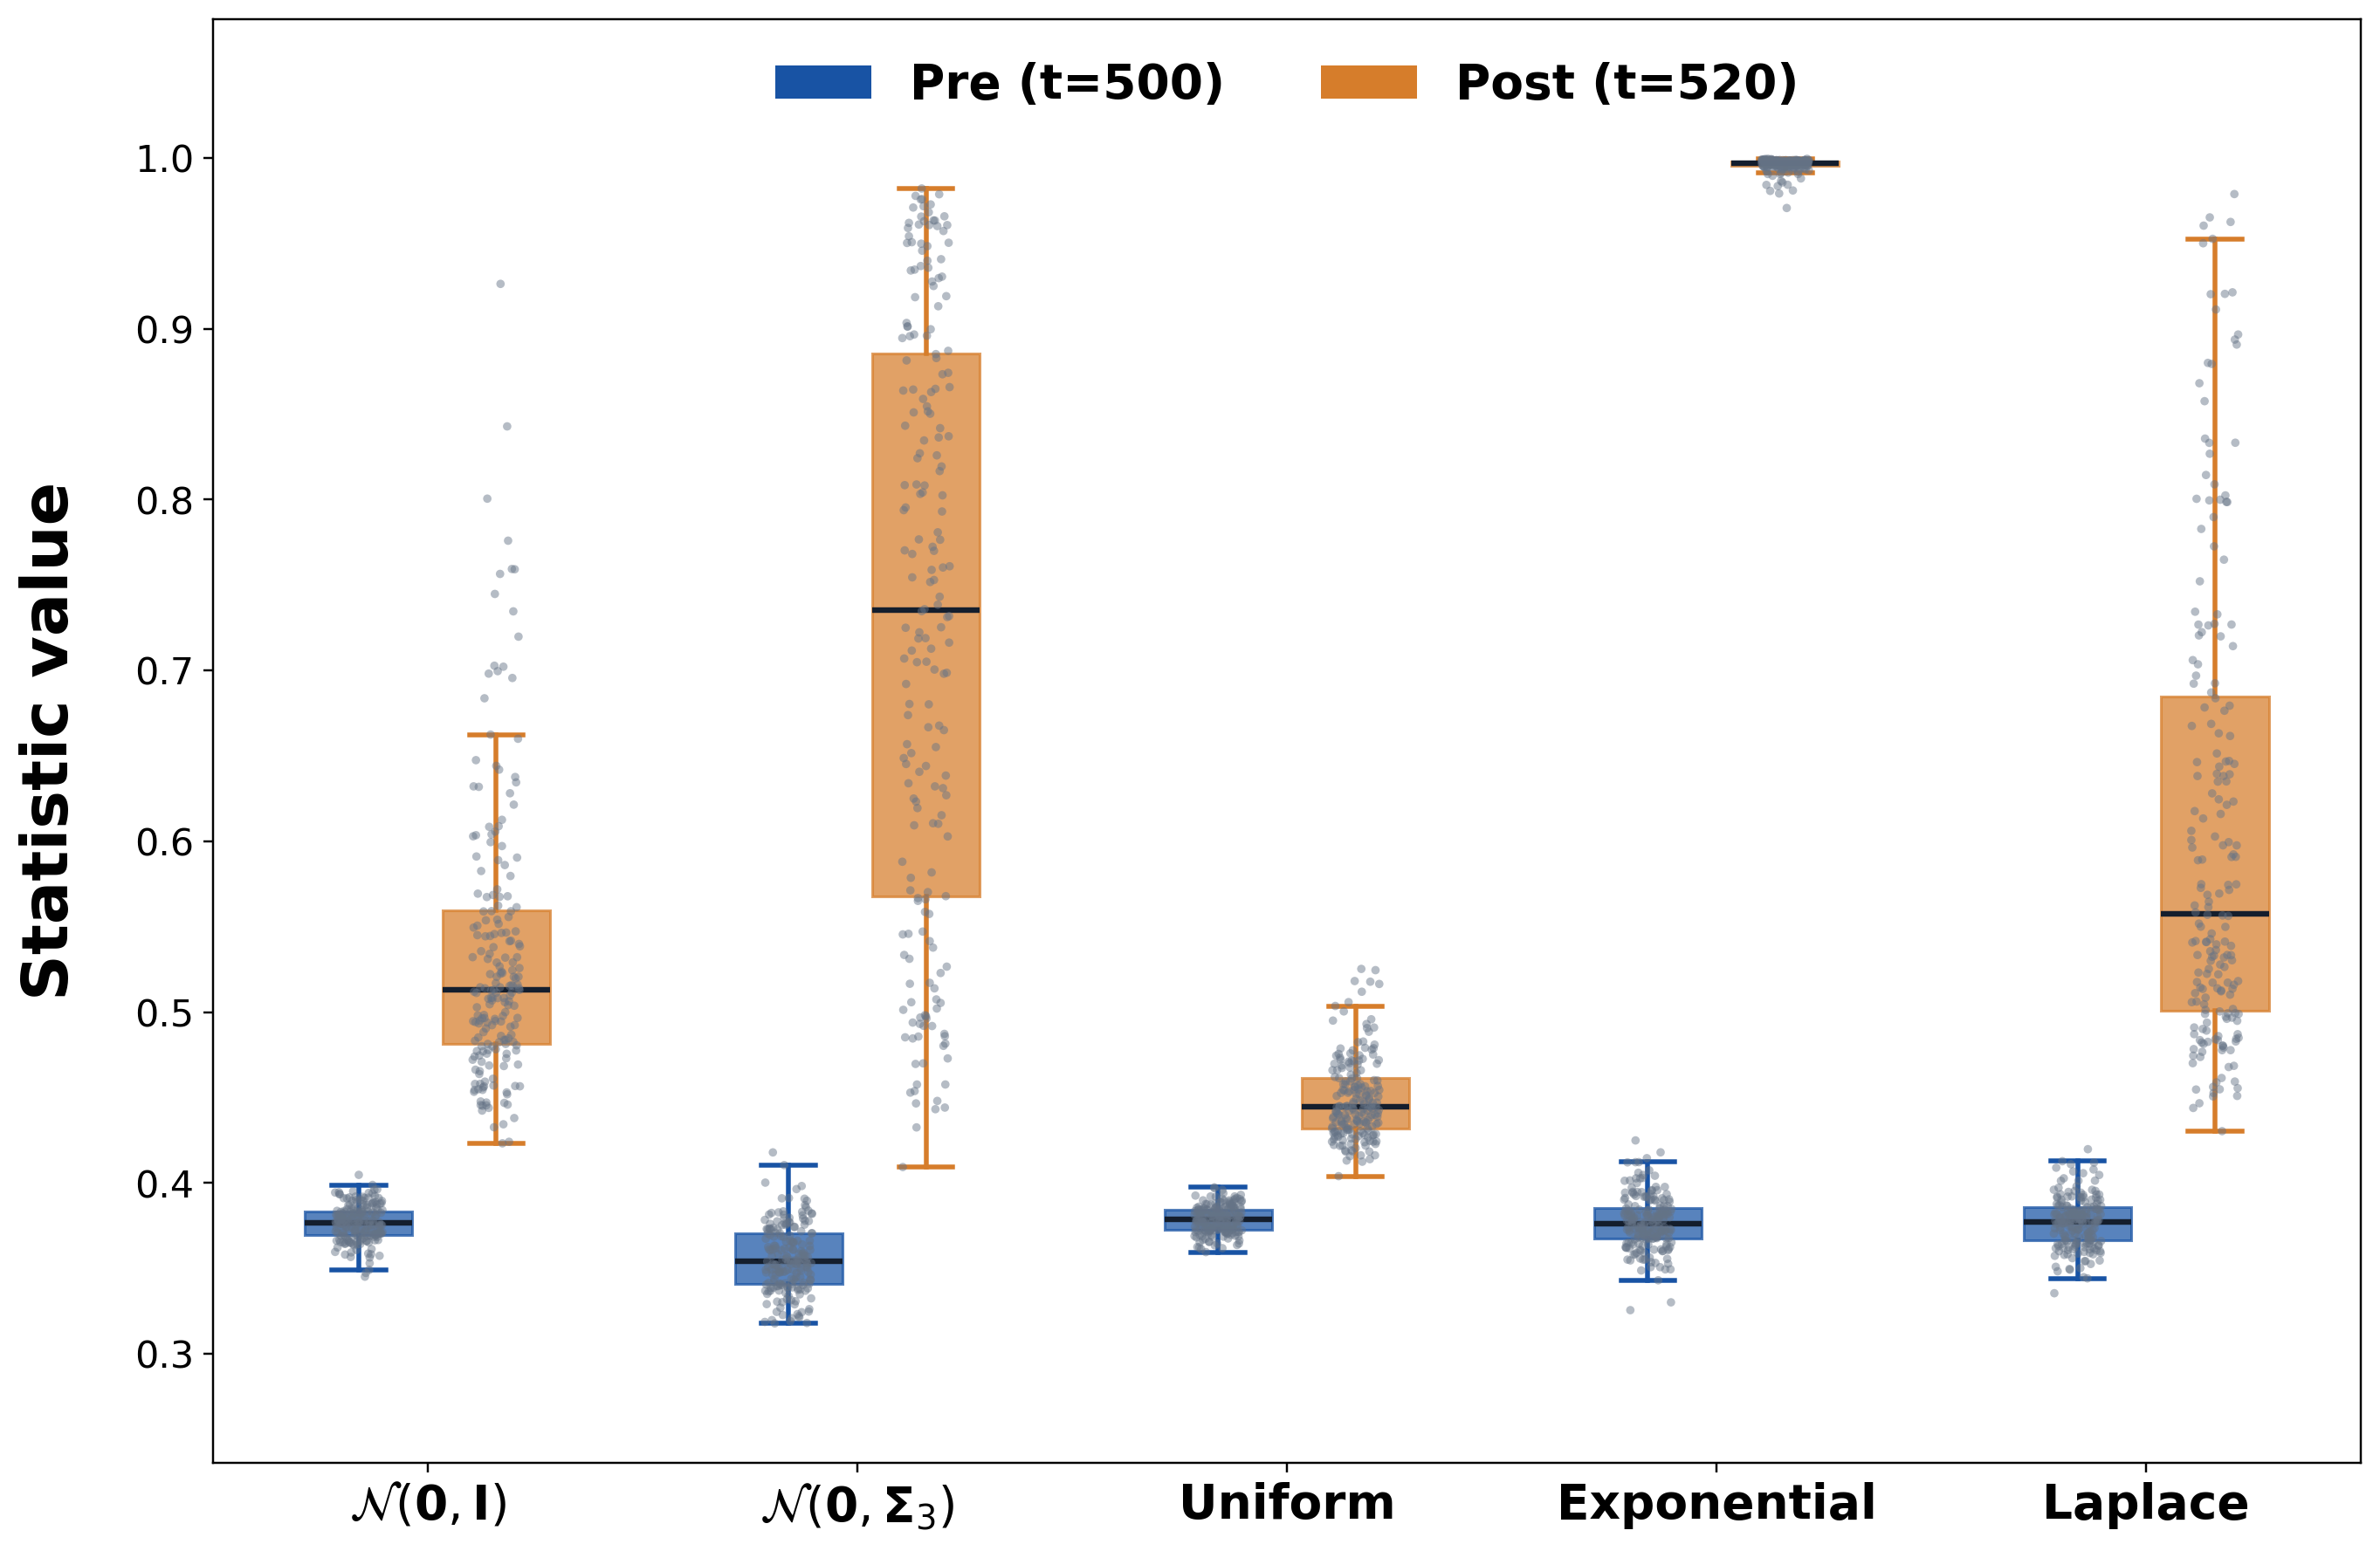

### pre/post empirical box plots: t=500 and t=530

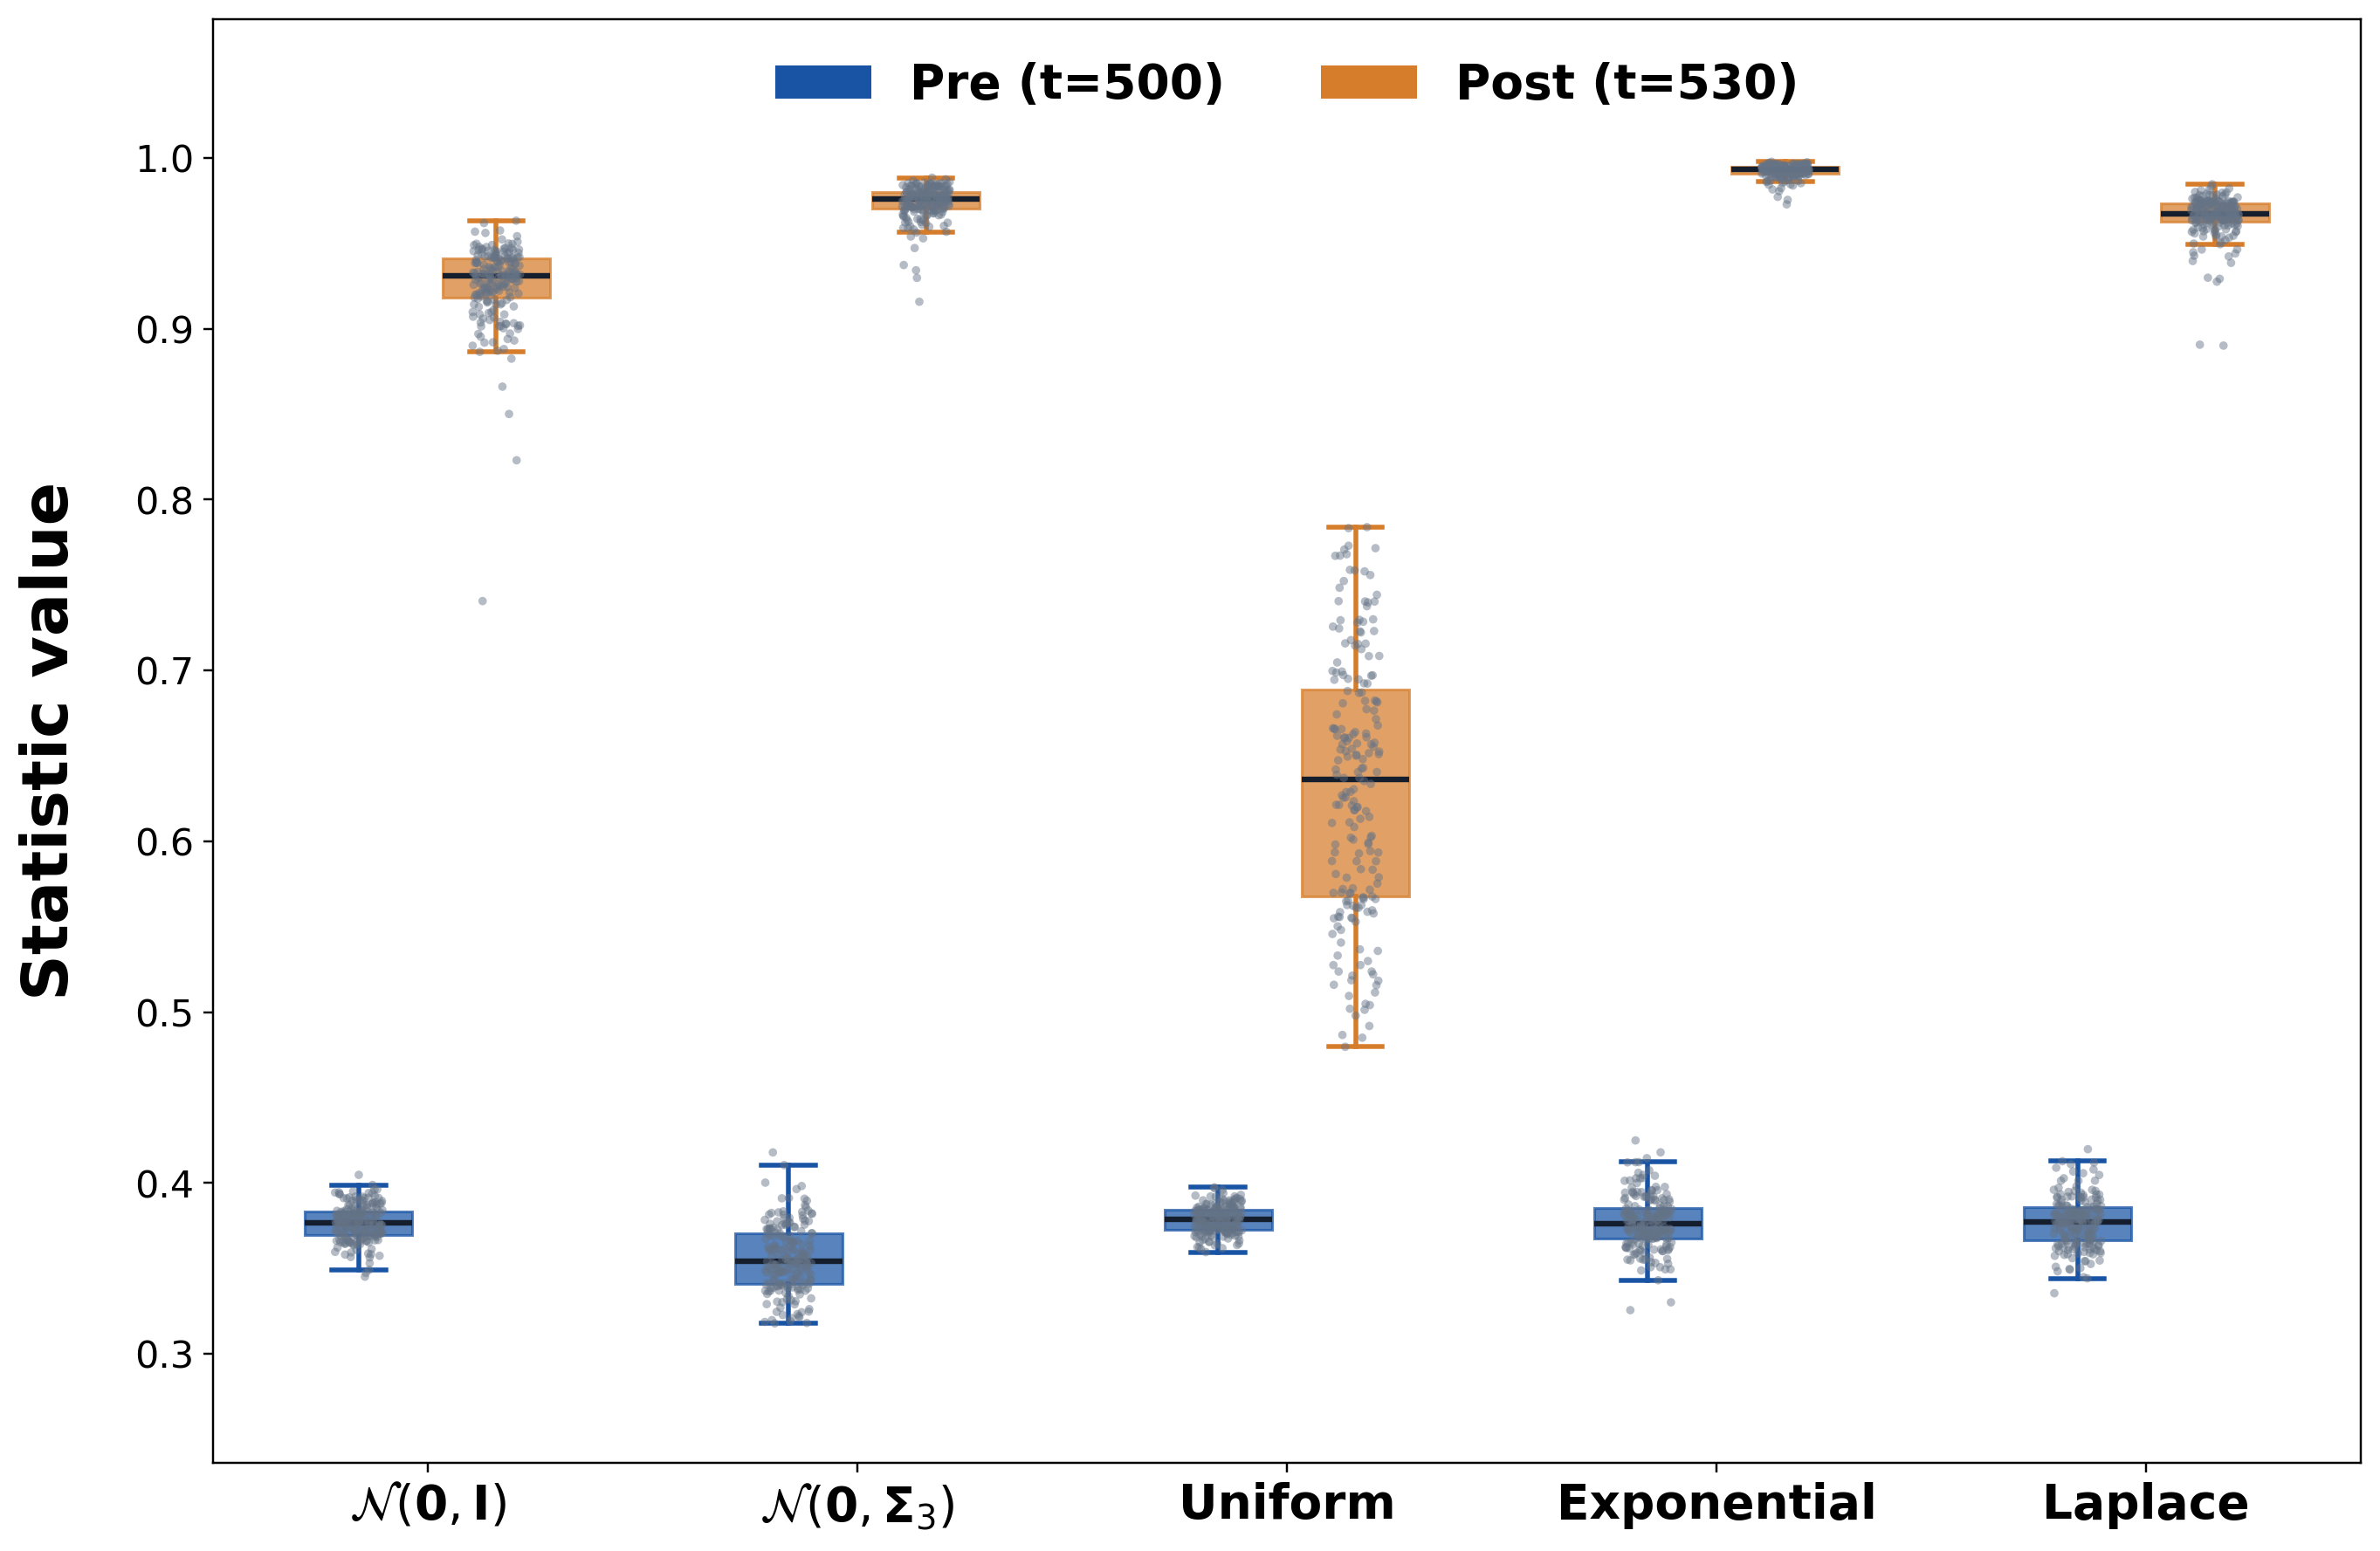

### pre/post empirical box plots: t=500 and t=540

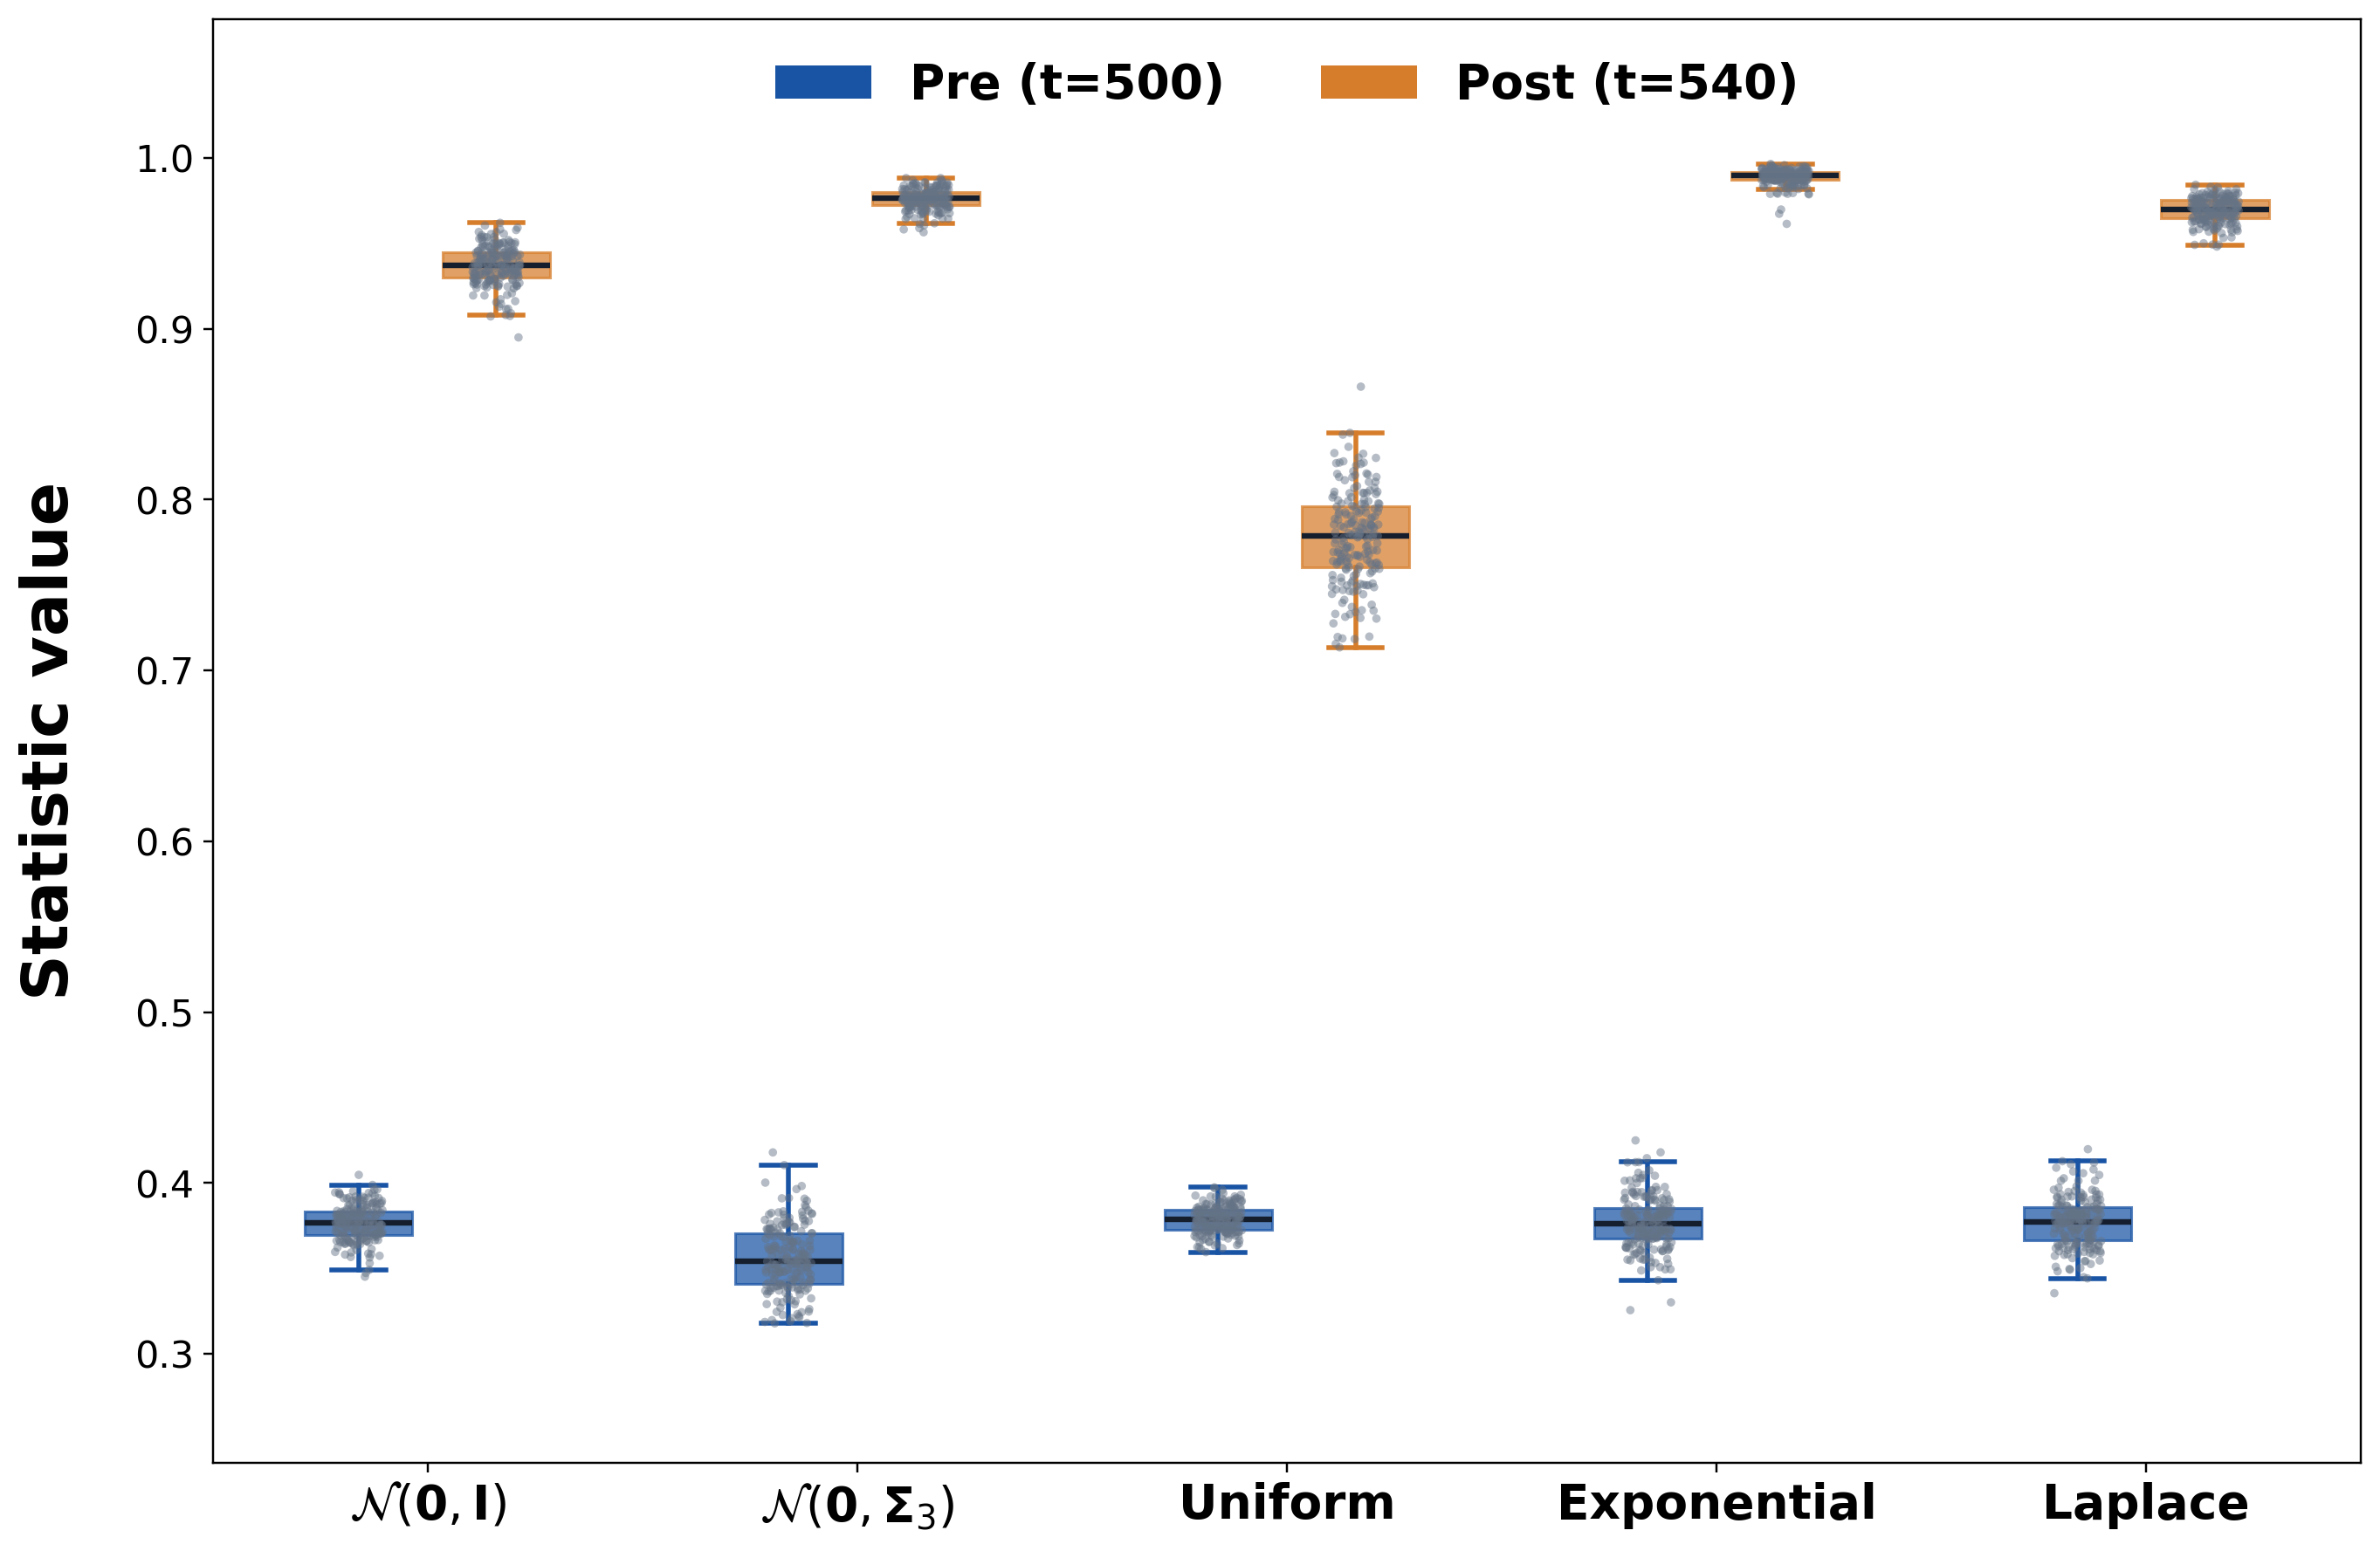

In [4]:
LABELS = {
    "gaussian_identity": r"$\mathbf{\mathcal{N}}(\mathbf{0},\mathbf{I})$",
    "gaussian_non_diagonal": r"$\mathbf{\mathcal{N}}(\mathbf{0},\mathbf{\Sigma}_3)$",
    "uniform": "Uniform", "exponential": "Exponential", "laplace": "Laplace",
}
PRE_COLOR, POST_COLOR = "#1853a4", "#d67d2b"


def plot_pre_post_boxes(pre_time, post_time, shared_limits):
    pre_idx, post_idx = TIMES.index(pre_time), TIMES.index(post_time)
    fig, ax = plt.subplots(figsize=(12.5, 8.2))
    centers = np.arange(len(DISTRIBUTIONS), dtype=float)
    for index, distribution in enumerate(DISTRIBUTIONS):
        for time_index, x, color in (
            (pre_idx, centers[index] - 0.16, PRE_COLOR),
            (post_idx, centers[index] + 0.16, POST_COLOR),
        ):
            values = box_values[distribution][:, time_index]
            bp = ax.boxplot(
                [values], positions=[x], widths=0.25, patch_artist=True,
                showfliers=False,
                medianprops={"color": "#141e2d", "linewidth": 2.1},
                whiskerprops={"color": color, "linewidth": 1.8},
                capprops={"color": color, "linewidth": 1.8},
            )
            bp["boxes"][0].set(facecolor=color, edgecolor=color, alpha=0.72)
            # Deterministic jitter, like the original empirical box figures.
            jitter = (((np.arange(len(values)) * 37) % 101) / 100 - 0.5) * 0.11
            ax.scatter(x + jitter, values, s=10, color="#657386",
                       alpha=0.48, edgecolors="none", zorder=3)

    from matplotlib.patches import Patch
    ax.legend(
        handles=[
            Patch(facecolor=PRE_COLOR, label=f"Pre (t={pre_time})"),
            Patch(facecolor=POST_COLOR, label=f"Post (t={post_time})"),
        ],
        frameon=False, ncol=2, loc="upper center",
        prop={"size": 18, "weight": "bold"},
    )
    ax.set_xticks(centers, [LABELS[name] for name in DISTRIBUTIONS],
                  fontsize=18, fontweight="bold")
    ax.set_ylabel("Statistic value", fontsize=24, fontweight="bold", labelpad=20)
    ax.set_xlim(-0.5, len(DISTRIBUTIONS) - 0.5)
    ax.set_ylim(*shared_limits)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(False)
    fig.tight_layout()
    return save_figure(fig, BOX_DIR, f"prepost_box_t{pre_time}_t{post_time}")


# All four comparisons share one empirical y-axis range.
all_box_values = np.concatenate([matrix.ravel() for matrix in box_values.values()])
low, high = float(all_box_values.min()), float(all_box_values.max())
padding = 0.12 * (high - low) if high > low else max(0.05, abs(high) * 0.05)
shared_limits = (low - padding, high + padding)

box_plot_outputs = {}
for post_time in TIMES[1:]:
    box_plot_outputs[post_time] = plot_pre_post_boxes(CHANGE_TIME, post_time, shared_limits)
    print(f"pre/post empirical box plots: t={CHANGE_TIME} and t={post_time}: "
          f"{box_plot_outputs[post_time][0]}")

if display is not None:
    for post_time, (png, _) in box_plot_outputs.items():
        display(Markdown(f"### pre/post empirical box plots: t={CHANGE_TIME} and t={post_time}"))
        display(Image(filename=str(png)))


### Combined sample paths across pre-change distributions

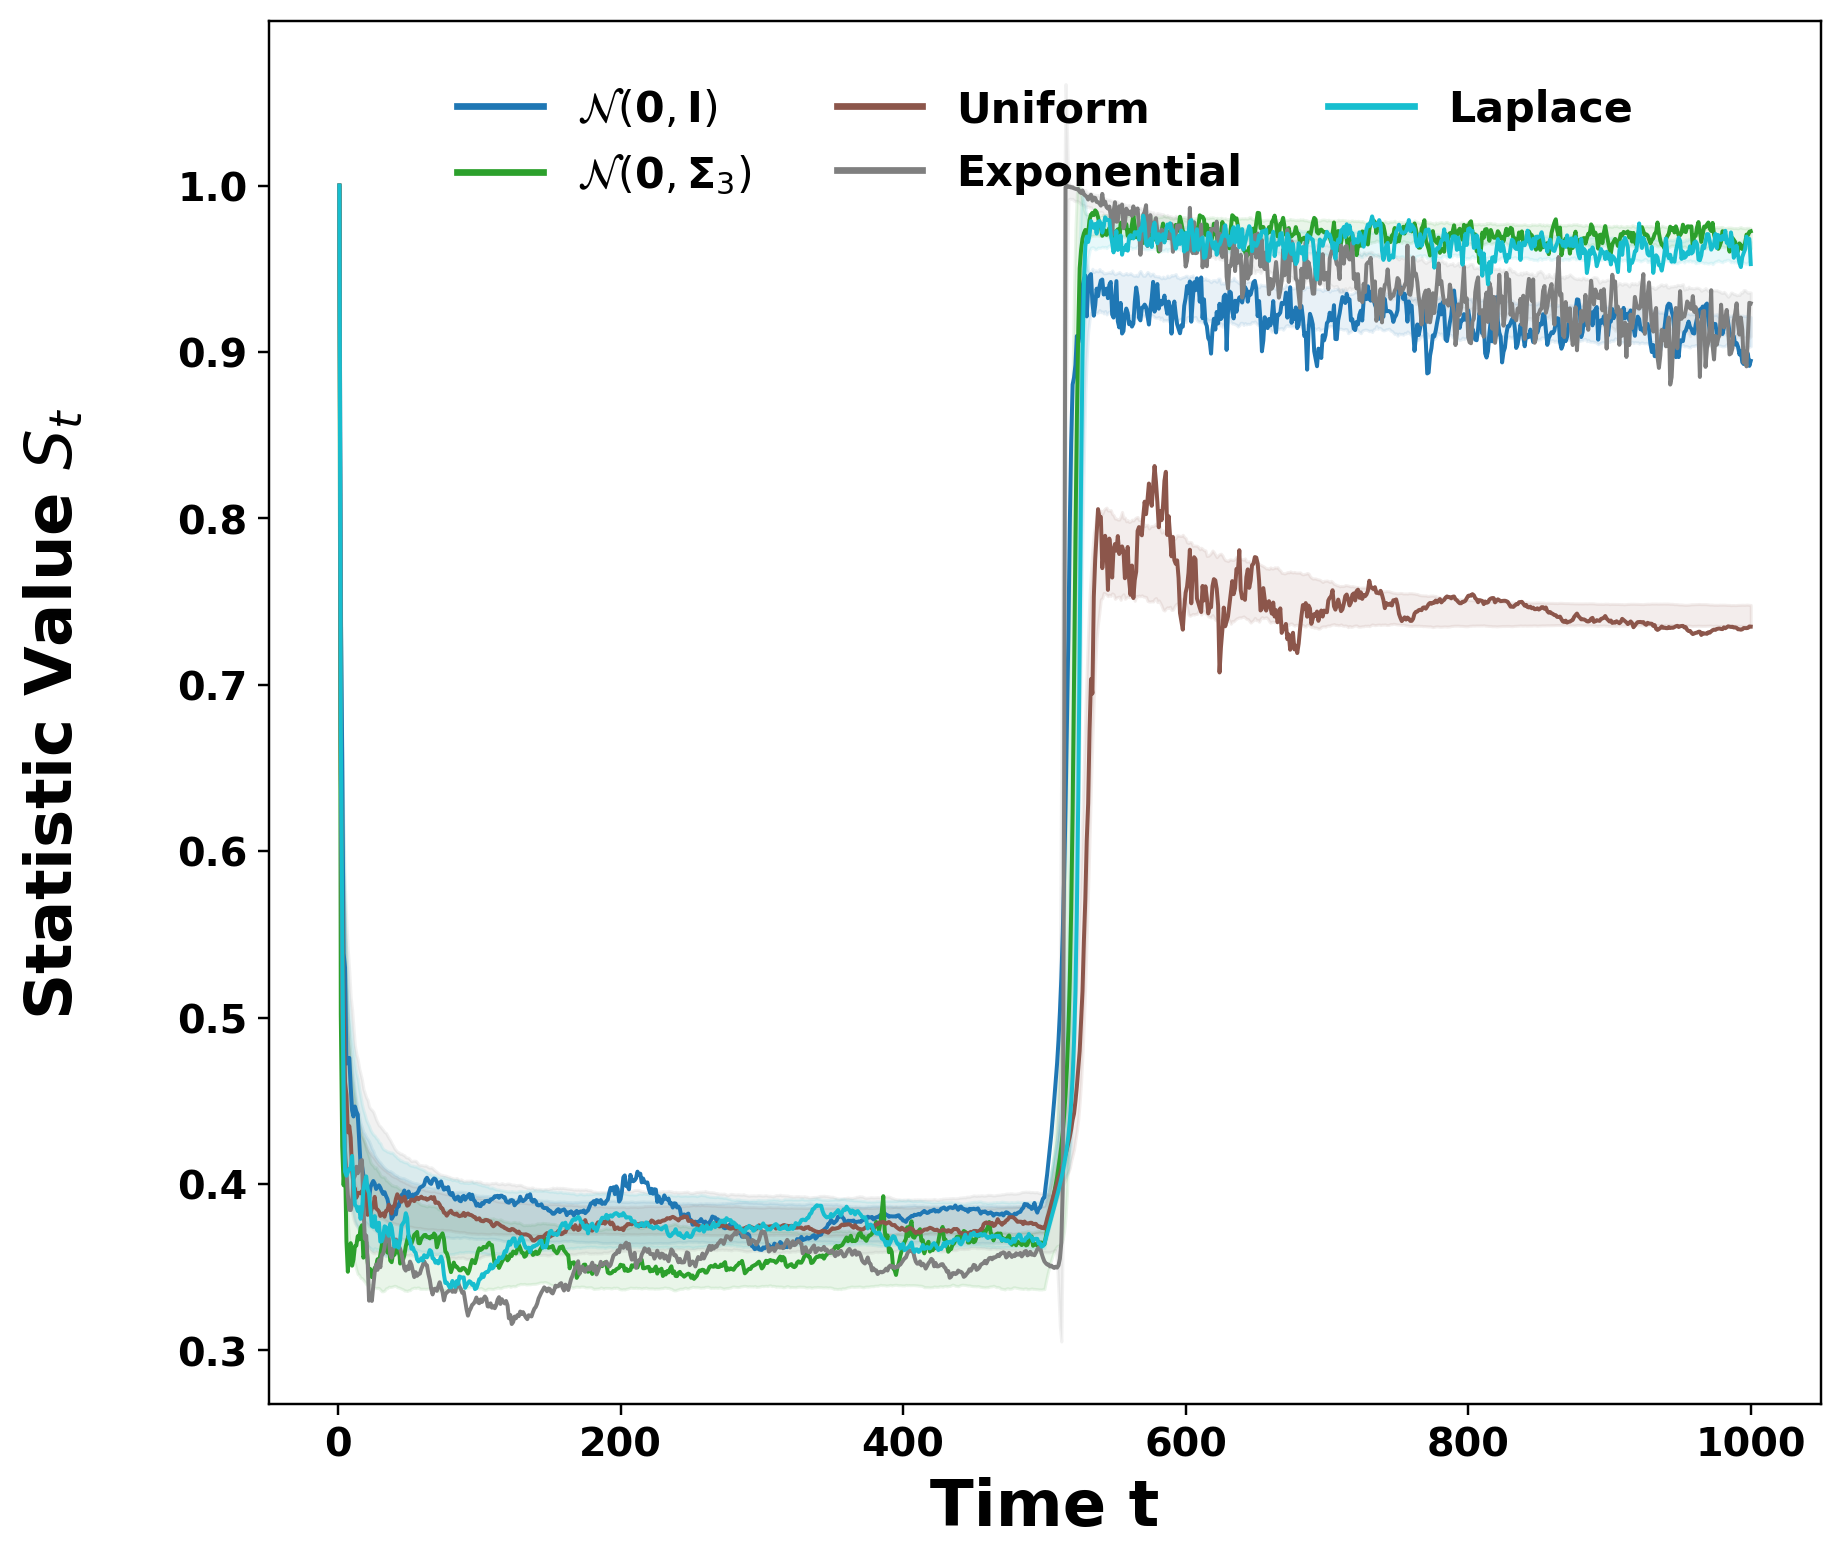

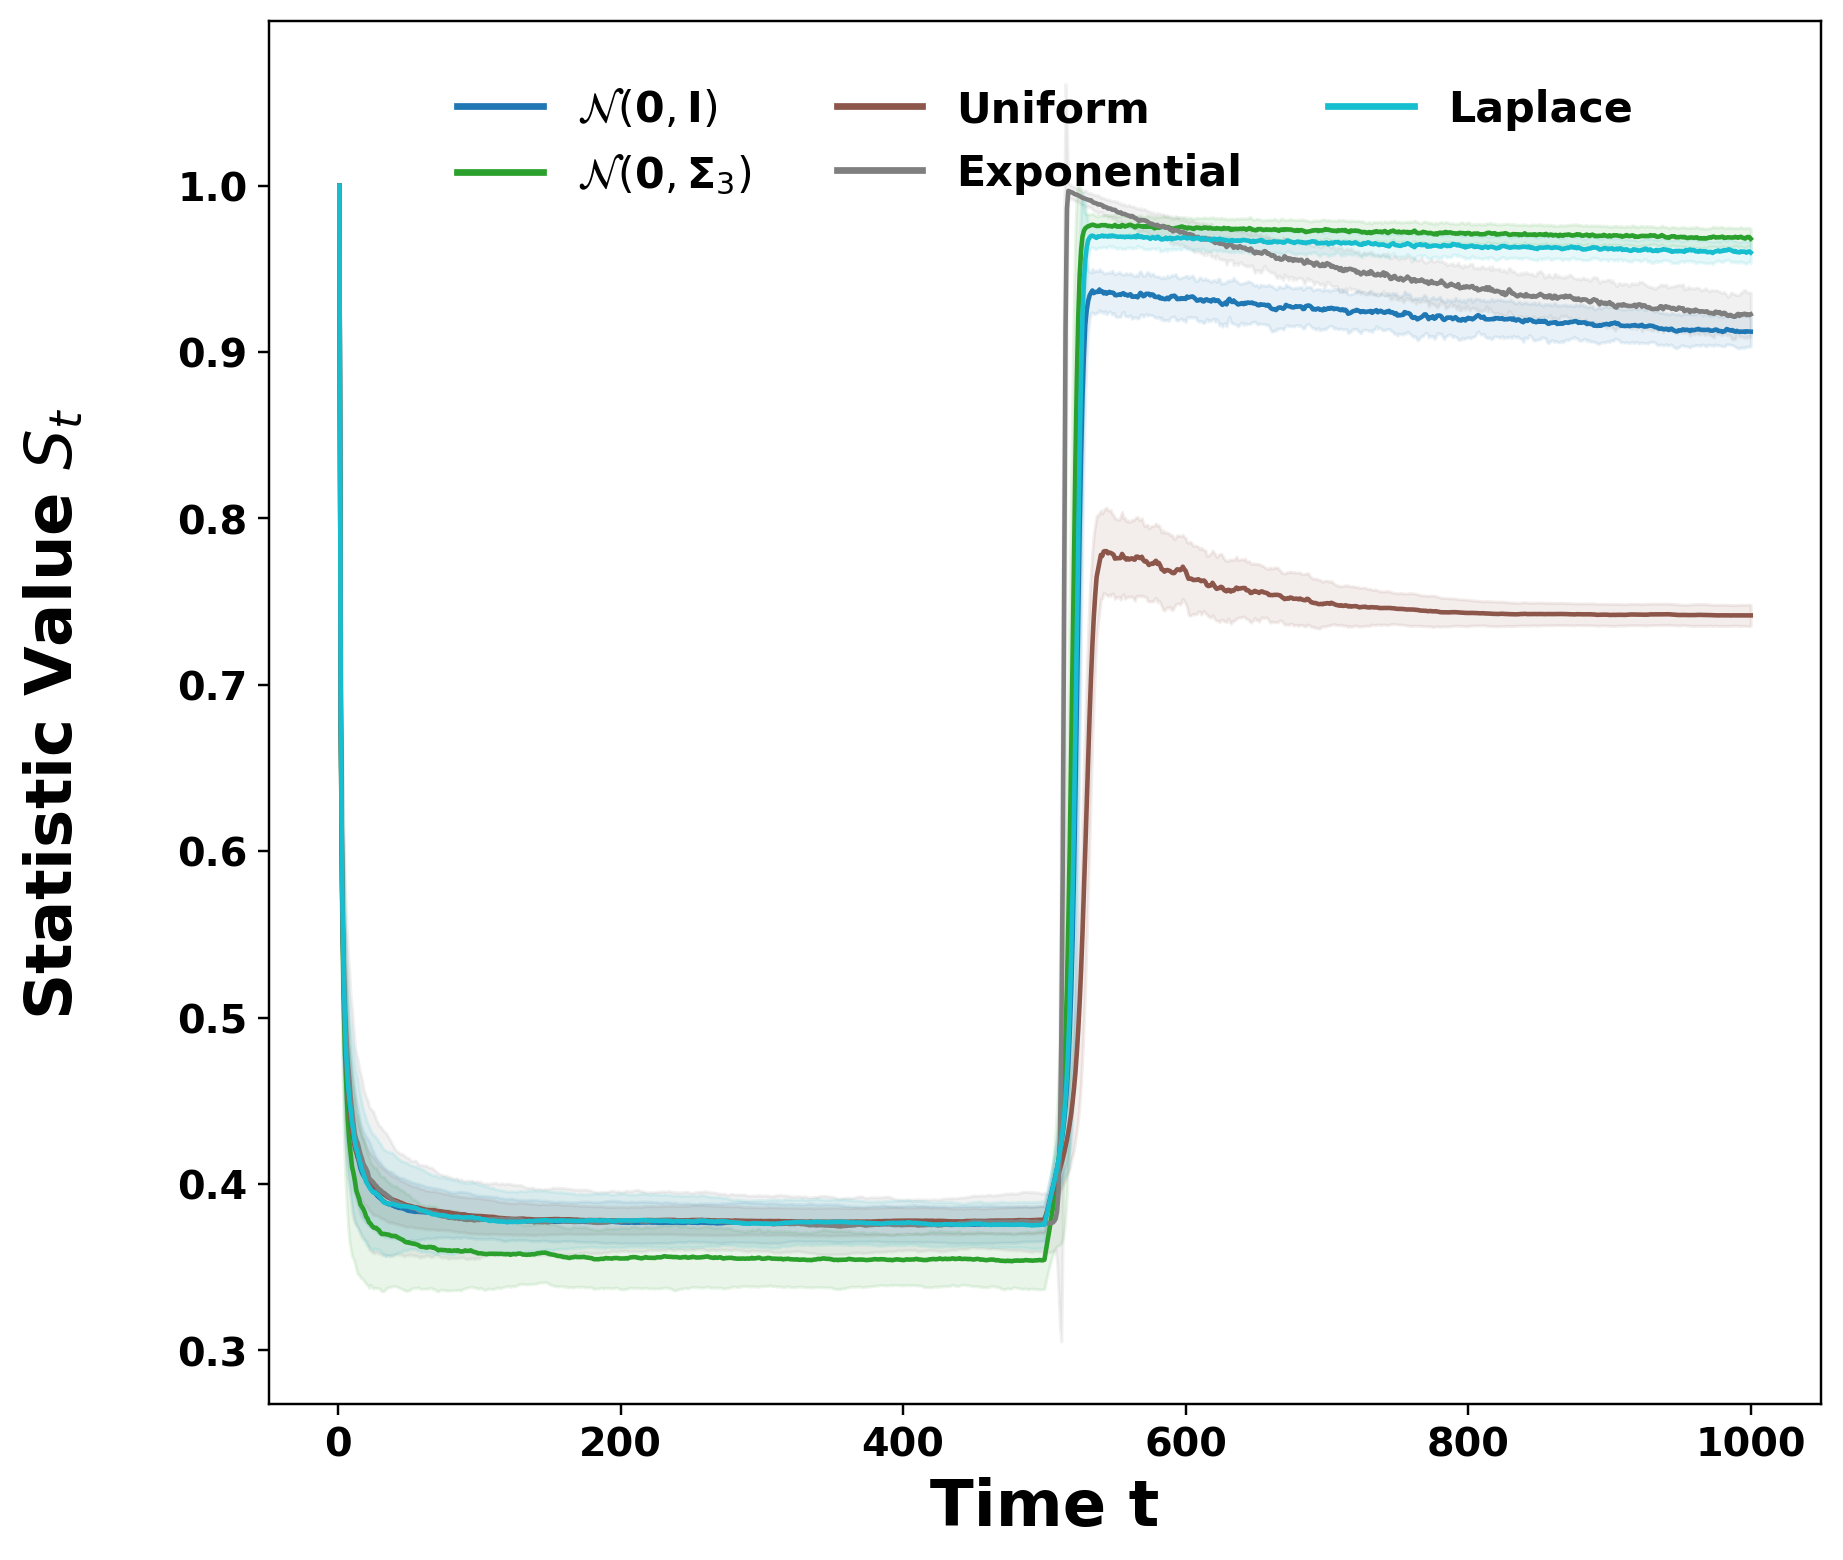

In [5]:
def plot_combined_paths(*, average=False):
    """Overlay the five pre-change distributions with the original ±1 SD bands."""
    from matplotlib.lines import Line2D

    fig, ax = plt.subplots(figsize=(8.5, 7.2))
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(DISTRIBUTIONS), 2)))
    times = np.arange(1, SAMPLE_PATH_MAX_TIME + 1)
    for color, distribution in zip(colors, DISTRIBUTIONS):
        stats = path_values[distribution]
        mean_path = stats.mean(axis=0)
        std_path = stats.std(axis=0, ddof=1)
        ax.fill_between(times, mean_path - std_path, mean_path + std_path,
                        color=color, alpha=0.10)
        ax.plot(times, mean_path if average else stats[0],
                color=color, linewidth=1.5 if average else 1.3)

    ax.set_xlabel("Time t", fontsize=21, fontweight="bold")
    ax.set_ylabel(r"Statistic Value $S_t$", fontsize=21, fontweight="bold", labelpad=30)
    ax.tick_params(axis="both", labelsize=13)
    for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        label.set_fontweight("bold")
    ax.grid(False)
    handles = [
        Line2D([0], [0], color=color, linewidth=2.2, label=LABELS[distribution])
        for color, distribution in zip(colors, DISTRIBUTIONS)
    ]
    ax.legend(handles=handles, loc="upper center",
              bbox_to_anchor=(0.5, 0.98), ncol=(len(handles) + 1) // 2,
              frameon=False, prop={"size": 14, "weight": "bold"})
    fig.tight_layout()

    suffix = "average_paths" if average else "individual_path_1"
    return save_figure(
        fig, PATH_DIR,
        f"all_prechange_cases_{suffix}",
    )


combined_plot_outputs = {}
for average in (False, True):
    combined_plot_outputs[average] = plot_combined_paths(average=average)
    print(f"Combined {'average' if average else 'individual'} sample paths "
          f"(horizontal legend): {combined_plot_outputs[average][0]}")

if display is not None:
    display(Markdown("### Combined sample paths across pre-change distributions"))
    for png, _ in combined_plot_outputs.values():
        display(Image(filename=str(png)))
